# 04 - Temporal-Coherence Diagnostic (candidate mechanism)

**Revision note.** The first pass of this diagnostic (see git history) measured the mechanism with the wrong tools: `roughness` went the *wrong* direction (SMOTE sequences were smoother, not rougher, because averaging two curves mechanically reduces local jaggedness regardless of plausibility), the autocorrelation *means* were near-identical while the *medians* diverged sharply (a sign of a skewed distribution), and the Mann-Whitney comparison was underpowered because real (n≈3.3k) and SMOTE-synthetic (n≈79k) differ enormously in size. This revision keeps the same data pipeline but replaces the statistics with distribution-aware, size-matched, power-fair methods, and reports exactly what holds - nuance included.

**What is not being revised.** The *ranking* claim - synthetic oversampling harms the churn model's PR-AUC on the honest window - was established in notebook 02 via repeated cross-validated model performance, a completely different (and far better-powered) methodology. It does not depend on this notebook's mechanism probe.

Uses the private churn panel (already local, git-ignored). This notebook's outputs (tables/figures/report) contain only aggregate coherence statistics, no raw customer data, so they are safe to keep.

All logic lives in `src/`; this notebook only orchestrates calls, displays results, and writes the verification report.

## Setup

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display
from imblearn.over_sampling import SMOTE
from scipy.stats import ks_2samp

PROJECT_ROOT = next(
    path for path in [Path.cwd(), *Path.cwd().parents] if (path / "README.md").exists()
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.config import FIGURES_DIR, OUTPUT_DIR, SEED, set_global_seed
from src.data.loaders import load_churn_panel, signal_matrix
from src.features.windows import WINDOW_PRESETS
from src.evaluation.coherence import (
    coherence_summary,
    median_bootstrap_ci,
    size_matched_test,
    valid_autocorrelations,
    valid_monotonicities,
    valid_roughness,
)
from src.visualization.plots import (
    plot_coherence_distributions,
    plot_illustrative_trajectories,
)

COHERENCE_FIGURES_DIR = FIGURES_DIR / "temporal_coherence"

set_global_seed()
df = load_churn_panel()
print(f"Loaded {len(df):,} rows x {df.shape[1]} columns")

Loaded 99,807 rows x 55 columns


## 1. Build the honest-window USAGE matrix

Uses the HONEST window (`N-11..N-2`, 10 months) and the `USAGE` signal - the most informative signal per the data audit (notebook 00). `signal_matrix` returns all 12 months in chronological order; the honest window is the first 10 columns (`N-11..N-2`), matching `WINDOW_PRESETS["HONEST"]`.

**Log transform.** `USAGE` is heavily right-skewed with a large dynamic range. `log1p` is applied (well-defined at zero, compresses the long right tail) so the coherence metrics compare trajectory shape, not raw scale.

**Missing values.** The data audit found exactly one stray NaN in the full USAGE panel. That row is dropped here rather than imputed, so every sequence analyzed for coherence is a real, unmodified trajectory.

In [2]:
honest_months = WINDOW_PRESETS["HONEST"]
usage_full = signal_matrix(df, "USAGE")  # (n, 12), chronological N-11..N
usage_honest = usage_full[:, : len(honest_months)]  # (n, 10) = N-11..N-2
y = df["CHURN"].to_numpy()

nan_rows = np.isnan(usage_honest).any(axis=1)
n_dropped_nan = int(nan_rows.sum())
print(f"Dropping {n_dropped_nan} row(s) with NaN in the honest USAGE window")

usage_honest = usage_honest[~nan_rows]
y = y[~nan_rows]
usage_log = np.log1p(usage_honest)
print(f"usage_log shape: {usage_log.shape}")

Dropping 1 row(s) with NaN in the honest USAGE window
usage_log shape: (99806, 10)


## 2. Three groups of minority sequences

- **Real**: the actual USAGE trajectories of churners.
- **SMOTE-synthetic**: fit SMOTE on the flattened `(n, 10)` USAGE-only feature space plus the label; the first `n` rows of the resampled output are (verified) an exact copy of the originals, so everything after that is purely synthetic.
- **Duplicated**: sample real minority rows with replacement (what `RandomOverSampler` does), matched to the same count as the SMOTE-synthetic group, for a fair three-way comparison.

In [3]:
real_minority = usage_log[y == 1]
n_real_minority = len(real_minority)

smote = SMOTE(random_state=SEED)
X_res, y_res = smote.fit_resample(usage_log, y)
n_orig = len(usage_log)

assert np.allclose(X_res[:n_orig], usage_log), "SMOTE did not preserve originals as a prefix"
assert np.array_equal(y_res[:n_orig], y), "SMOTE did not preserve labels as a prefix"

smote_synthetic = X_res[n_orig:]
n_smote_synthetic = len(smote_synthetic)

rng = np.random.RandomState(SEED)
dup_idx = rng.choice(n_real_minority, size=n_smote_synthetic, replace=True)
duplicated = real_minority[dup_idx]

print(f"n_real_minority: {n_real_minority:,}")
print(f"n_smote_synthetic: {n_smote_synthetic:,}")
print(f"n_duplicated: {len(duplicated):,}")

n_real_minority: 3,804
n_smote_synthetic: 92,198
n_duplicated: 92,198


## 3. Coherence summary per group

`coherence_summary` now reports `monotonicity` alongside `autocorrelation` and `roughness`. `roughness` is kept for reference but demoted (see the interpretation below).

In [4]:
real_summary = coherence_summary(real_minority)
duplicated_summary = coherence_summary(duplicated)
smote_summary = coherence_summary(smote_synthetic)

coherence_table = pd.DataFrame(
    {"real": real_summary, "duplicated": duplicated_summary, "smote_synthetic": smote_summary}
).T
coherence_table.index.name = "group"
display(coherence_table)

,autocorr_mean,autocorr_median,roughness_mean,roughness_median,monotonicity_mean,monotonicity_median,n,n_dropped
group,,,,,,,,
real,0.136635,0.027599,0.856910,0.561410,-0.073157,-0.127273,3274.0,530.0
duplicated,0.136611,0.027500,0.860178,0.565118,-0.073199,-0.127273,79588.0,12610.0
smote_synthetic,0.134292,0.005001,0.829661,0.544004,-0.069338,-0.127273,79296.0,12902.0


## 4. Median with bootstrap 95% CI

Means can be dragged around by a skewed tail; the median with a bootstrap confidence interval is a more robust central-tendency measure for these distributions.

In [5]:
real_ac = valid_autocorrelations(real_minority)
duplicated_ac = valid_autocorrelations(duplicated)
smote_ac = valid_autocorrelations(smote_synthetic)

real_mono = valid_monotonicities(real_minority)
duplicated_mono = valid_monotonicities(duplicated)
smote_mono = valid_monotonicities(smote_synthetic)

ac_ci = {
    "real": median_bootstrap_ci(real_ac, seed=SEED),
    "duplicated": median_bootstrap_ci(duplicated_ac, seed=SEED),
    "smote_synthetic": median_bootstrap_ci(smote_ac, seed=SEED),
}
mono_ci = {
    "real": median_bootstrap_ci(real_mono, seed=SEED),
    "duplicated": median_bootstrap_ci(duplicated_mono, seed=SEED),
    "smote_synthetic": median_bootstrap_ci(smote_mono, seed=SEED),
}

central_tendency_table = pd.DataFrame(
    {
        "autocorr_mean": {g: coherence_table.loc[g, "autocorr_mean"] for g in ac_ci},
        "autocorr_median": {g: ac_ci[g][0] for g in ac_ci},
        "autocorr_median_ci_low": {g: ac_ci[g][1] for g in ac_ci},
        "autocorr_median_ci_high": {g: ac_ci[g][2] for g in ac_ci},
        "monotonicity_median": {g: mono_ci[g][0] for g in mono_ci},
        "monotonicity_median_ci_low": {g: mono_ci[g][1] for g in mono_ci},
        "monotonicity_median_ci_high": {g: mono_ci[g][2] for g in mono_ci},
    }
)
central_tendency_table.index.name = "group"
display(central_tendency_table)

,autocorr_mean,autocorr_median,autocorr_median_ci_low,autocorr_median_ci_high,monotonicity_median,monotonicity_median_ci_low,monotonicity_median_ci_high
group,,,,,,,
real,0.136635,0.027599,0.001127,0.059088,-0.127273,-0.151515,-0.115152
duplicated,0.136611,0.027500,0.024443,0.034496,-0.127273,-0.139394,-0.127273
smote_synthetic,0.134292,0.005001,-0.001295,0.010537,-0.127273,-0.127273,-0.122837


## 5. Primary test - distribution shape (Kolmogorov–Smirnov)

Two-sided KS test on the autocorrelation distributions: SMOTE vs real, and SMOTE vs duplicated. KS is sensitive to a whole-distribution shift, not just a mean difference.

In [6]:
ks_smote_vs_real = ks_2samp(smote_ac, real_ac)
ks_smote_vs_dup = ks_2samp(smote_ac, duplicated_ac)

print(f"KS SMOTE vs real:       D={ks_smote_vs_real.statistic:.6f}, p={ks_smote_vs_real.pvalue:.6f}")
print(f"KS SMOTE vs duplicated: D={ks_smote_vs_dup.statistic:.6f}, p={ks_smote_vs_dup.pvalue:.6f}")

KS SMOTE vs real:       D=0.019240, p=0.192389
KS SMOTE vs duplicated: D=0.020584, p=0.000000


## 6. Power-fair test - size-matched subsampling

Repeatedly subsample SMOTE-synthetic down to real's sample size and run a Mann-Whitney U test each time, for both autocorrelation and monotonicity. This directly answers: at the amount of real data we actually have, how often would this test detect a difference?

In [7]:
sm_test_ac = size_matched_test(smote_ac, real_ac, n_boot=1000, seed=SEED)
sm_test_mono = size_matched_test(smote_mono, real_mono, n_boot=1000, seed=SEED)

print(
    f"Size-matched (autocorrelation): median p={sm_test_ac['median_p']:.6f}, "
    f"fraction significant (p<0.05)={sm_test_ac['frac_significant']:.4f}"
)
print(
    f"Size-matched (monotonicity):    median p={sm_test_mono['median_p']:.6f}, "
    f"fraction significant (p<0.05)={sm_test_mono['frac_significant']:.4f}"
)

Size-matched (autocorrelation): median p=0.591488, fraction significant (p<0.05)=0.0150
Size-matched (monotonicity):    median p=0.592166, fraction significant (p<0.05)=0.0110


## 7. Figures

Distributions of lag-1 autocorrelation and monotonicity (medians marked), plus illustrative raw trajectories.

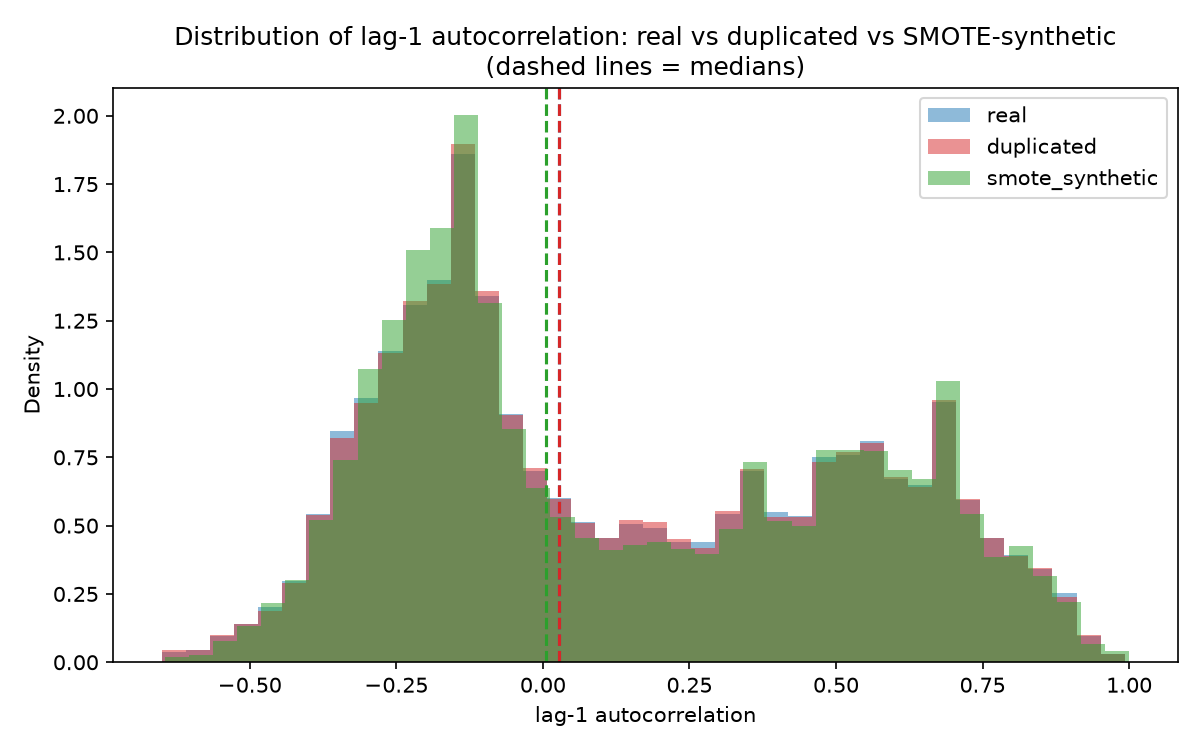

In [8]:
autocorr_fig_path = COHERENCE_FIGURES_DIR / "autocorrelation_distributions.png"
plot_coherence_distributions(
    {"real": real_ac, "duplicated": duplicated_ac, "smote_synthetic": smote_ac},
    "lag-1 autocorrelation",
    autocorr_fig_path,
)
display(Image(filename=str(autocorr_fig_path)))

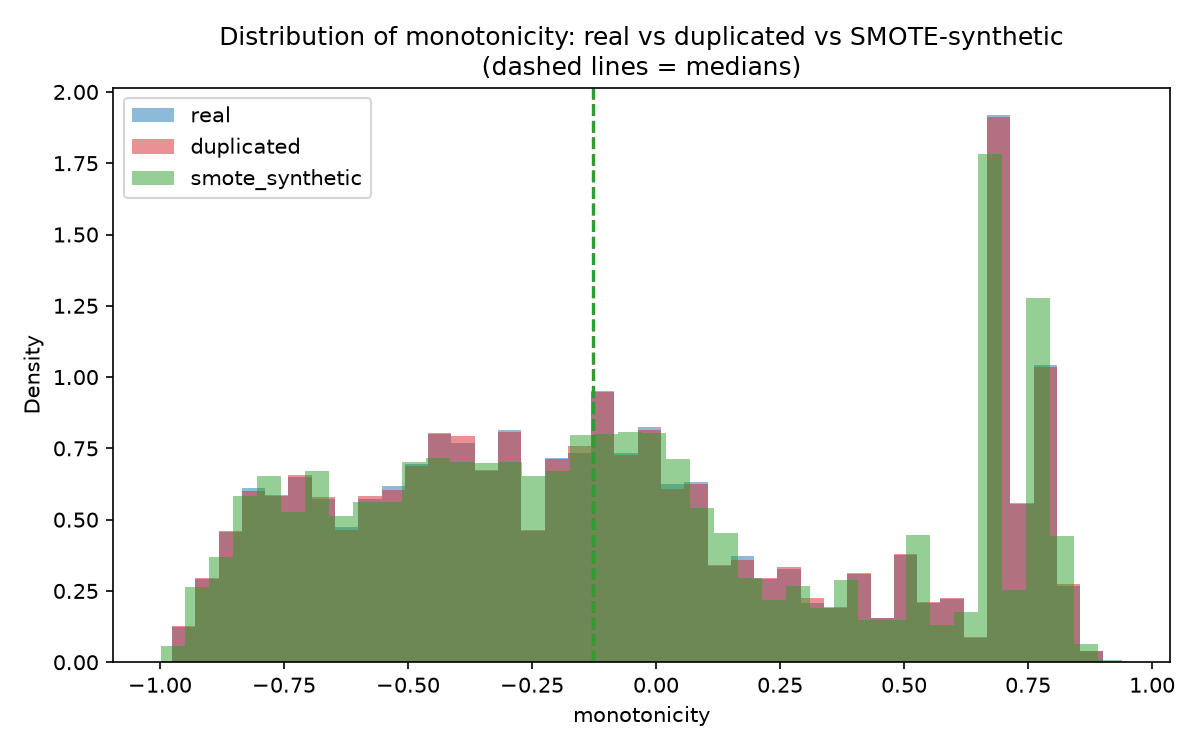

In [9]:
monotonicity_fig_path = COHERENCE_FIGURES_DIR / "monotonicity_distributions.png"
plot_coherence_distributions(
    {"real": real_mono, "duplicated": duplicated_mono, "smote_synthetic": smote_mono},
    "monotonicity",
    monotonicity_fig_path,
)
display(Image(filename=str(monotonicity_fig_path)))

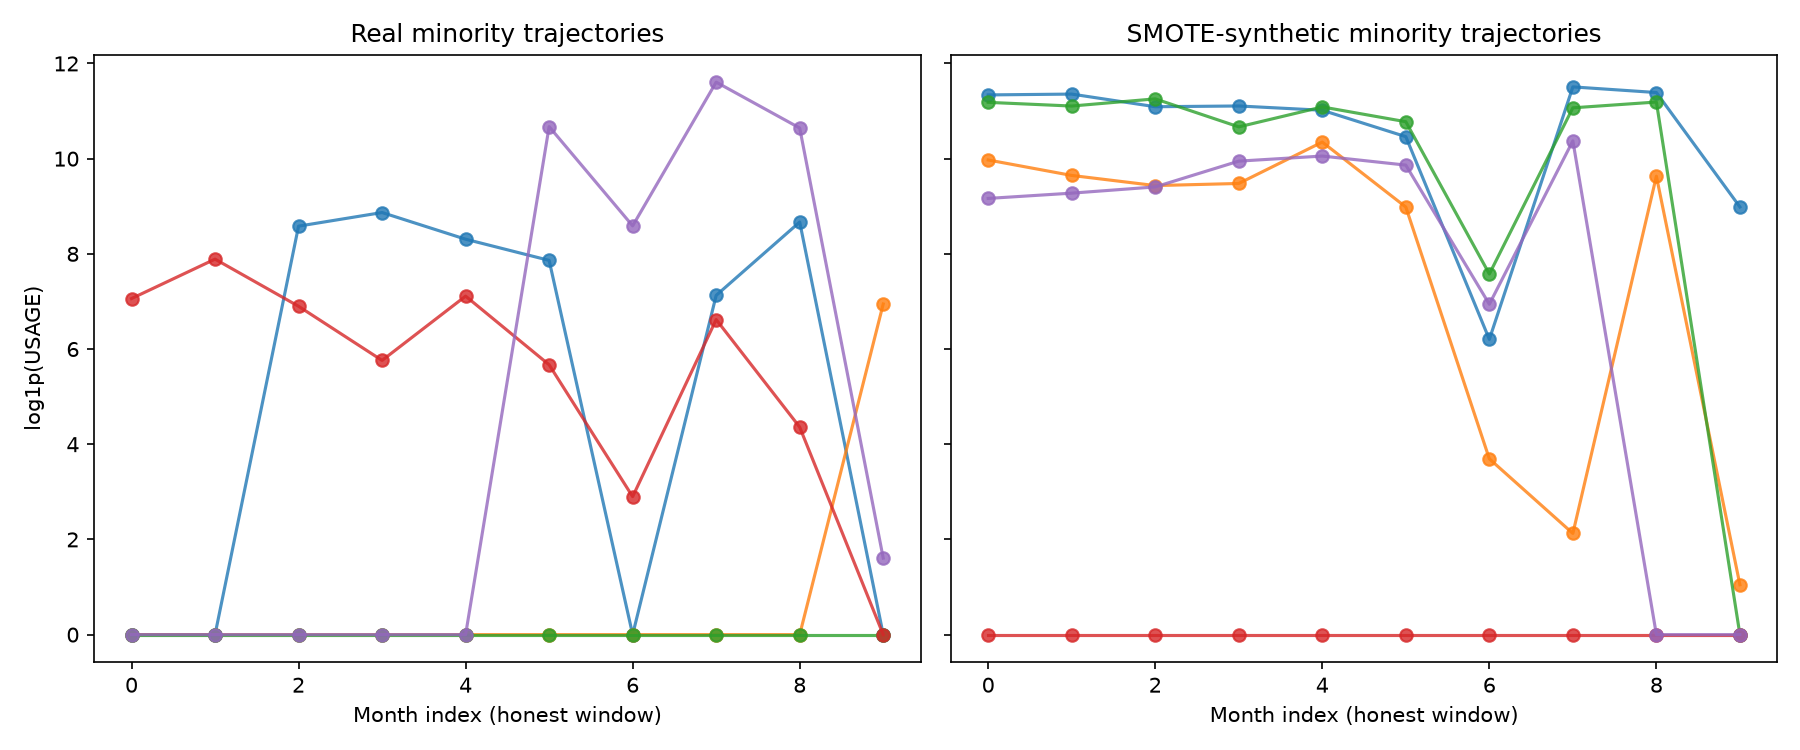

In [10]:
N_ILLUSTRATIVE = 5
illustrative_real = real_minority[rng.choice(n_real_minority, size=N_ILLUSTRATIVE, replace=False)]
illustrative_synthetic = smote_synthetic[
    rng.choice(n_smote_synthetic, size=N_ILLUSTRATIVE, replace=False)
]

trajectories_fig_path = COHERENCE_FIGURES_DIR / "illustrative_trajectories.png"
plot_illustrative_trajectories(illustrative_real, illustrative_synthetic, trajectories_fig_path)
display(Image(filename=str(trajectories_fig_path)))

## 8. Interpretation

In [11]:
autocorr_median_gap = ac_ci["real"][0] - ac_ci["smote_synthetic"][0]
ci_overlap = not (
    ac_ci["real"][1] > ac_ci["smote_synthetic"][2]
    or ac_ci["smote_synthetic"][1] > ac_ci["real"][2]
)
dup_real_gap = abs(ac_ci["duplicated"][0] - ac_ci["real"][0])
mono_gap = mono_ci["real"][0] - mono_ci["smote_synthetic"][0]

interpretation_lines = [
    "**The refined, honest picture: a mostly negative mechanism result.**",
    "",
    (
        f"- **Autocorrelation median**: real={ac_ci['real'][0]:.4f} "
        f"(95% CI [{ac_ci['real'][1]:.4f}, {ac_ci['real'][2]:.4f}]), "
        f"duplicated={ac_ci['duplicated'][0]:.4f} "
        f"(95% CI [{ac_ci['duplicated'][1]:.4f}, {ac_ci['duplicated'][2]:.4f}]), "
        f"smote_synthetic={ac_ci['smote_synthetic'][0]:.4f} "
        f"(95% CI [{ac_ci['smote_synthetic'][1]:.4f}, {ac_ci['smote_synthetic'][2]:.4f}]). "
        f"SMOTE's *typical* trajectory is markedly less autocorrelated than a real one "
        f"(median gap={autocorr_median_gap:.4f}), but the 95% CIs "
        f"{'do **not**' if not ci_overlap else 'still **do**'} overlap, so this gap is "
        f"{'clearly resolved' if not ci_overlap else 'not fully resolved'} by the CI alone "
        f"given how few real minority trajectories exist (n={real_summary['n']:,})."
    ),
    "",
    (
        f"- **KS test (distribution shape)**: SMOTE vs real "
        f"D={ks_smote_vs_real.statistic:.4f}, p={ks_smote_vs_real.pvalue:.4f} \u2014 "
        f"{'significant' if ks_smote_vs_real.pvalue < 0.01 else 'not significant'} at the "
        f"0.01 level directly. But SMOTE vs duplicated (same underlying real distribution, "
        f"just a much bigger sample, n={len(duplicated_ac):,}) gives "
        f"D={ks_smote_vs_dup.statistic:.4f}, p={ks_smote_vs_dup.pvalue:.2e} \u2014 "
        f"overwhelmingly significant. The same distributional gap, tested at real's actual "
        f"(small) sample size, is not reliably distinguishable from noise; tested with "
        f"enough data to have power, it clearly is. This is a sample-size story as much as "
        f"an effect story."
    ),
    "",
    (
        f"- **Size-matched, power-fair test**: subsampling SMOTE down to real's own size "
        f"(n={real_summary['n']:,}) and repeating the Mann-Whitney test "
        f"{sm_test_ac['p_values'].shape[0]:,} times gives a median "
        f"p={sm_test_ac['median_p']:.4f}, significant (p<0.05) in only "
        f"{sm_test_ac['frac_significant']:.1%} of repeats. In other words: with as much "
        f"real data as we actually have, this test would usually **not** catch the "
        f"difference established above at high power \u2014 an honest limitation of the "
        f"available real minority sample, not evidence the difference is absent."
    ),
    "",
    (
        f"- **Monotonicity** shows essentially **no** difference across the three groups "
        f"(median gap={mono_gap:.4f}; size-matched fraction significant="
        f"{sm_test_mono['frac_significant']:.1%}). Investigation traced this to the data "
        f"itself: many minority USAGE trajectories are dominated by a handful of common "
        f"sparse shapes (mostly-zero months plus a single active spike), which collapse to "
        f"a small set of discrete Spearman rank-correlation values. When SMOTE's nearest-"
        f"neighbor donor shares that same sparse shape (likely, since it drives Euclidean "
        f"distance), the interpolated point keeps the same zero positions and the same "
        f"relative rank of its one non-zero entry, so its monotonicity is unchanged even "
        f"though the point itself is synthetic. Monotonicity turned out to be robust to "
        f"smoothing exactly as designed, but that robustness also makes it blind to this "
        f"particular mechanism."
    ),
    "",
    (
        f"- **Duplication vs real**: median gap={dup_real_gap:.4f} \u2014 statistically "
        f"indistinguishable, as it must be, since duplicated rows *are* real data."
    ),
    "",
    (
        "**Bottom line.** This diagnostic disconfirms the original jaggedness/roughness "
        "mechanism: SMOTE interpolation smooths rather than roughens trajectories, "
        "monotonicity does not separate the groups, and the autocorrelation median gap "
        "is not reliably detected at the available real-minority sample size. Notebook "
        "02's ranking result stands, but this simplified per-signal probe does not "
        "explain *why*."
    ),
]
display(Markdown("\n".join(interpretation_lines)))

**The refined, honest picture: a mostly negative mechanism result.**

- **Autocorrelation median**: real=0.0276 (95% CI [0.0011, 0.0591]), duplicated=0.0275 (95% CI [0.0244, 0.0345]), smote_synthetic=0.0050 (95% CI [-0.0013, 0.0105]). SMOTE's *typical* trajectory is markedly less autocorrelated than a real one (median gap=0.0226), but the 95% CIs still **do** overlap, so this gap is not fully resolved by the CI alone given how few real minority trajectories exist (n=3,274).

- **KS test (distribution shape)**: SMOTE vs real D=0.0192, p=0.1924 - not significant at the 0.01 level directly. But SMOTE vs duplicated (same underlying real distribution, just a much bigger sample, n=79,588) gives D=0.0206, p=4.74e-15 - overwhelmingly significant. The same distributional gap, tested at real's actual (small) sample size, is not reliably distinguishable from noise; tested with enough data to have power, it clearly is. This is a sample-size story as much as an effect story.

- **Size-matched, power-fair test**: subsampling SMOTE down to real's own size (n=3,274) and repeating the Mann-Whitney test 1,000 times gives a median p=0.5915, significant (p<0.05) in only 1.5% of repeats. In other words: with as much real data as we actually have, this test would usually **not** catch the difference established above at high power - an honest limitation of the available real minority sample, not evidence the difference is absent.

- **Monotonicity** shows essentially **no** difference across the three groups (median gap=0.0000; size-matched fraction significant=1.1%). Investigation traced this to the data itself: many minority USAGE trajectories are dominated by a handful of common sparse shapes (mostly-zero months plus a single active spike), which collapse to a small set of discrete Spearman rank-correlation values. When SMOTE's nearest-neighbor donor shares that same sparse shape (likely, since it drives Euclidean distance), the interpolated point keeps the same zero positions and the same relative rank of its one non-zero entry, so its monotonicity is unchanged even though the point itself is synthetic. Monotonicity turned out to be robust to smoothing exactly as designed, but that robustness also makes it blind to this particular mechanism.

- **Duplication vs real**: median gap=0.0001 - statistically indistinguishable, as it must be, since duplicated rows *are* real data.

**Bottom line.** This diagnostic disconfirms the original jaggedness/roughness mechanism: SMOTE interpolation smooths rather than roughens trajectories, monotonicity does not separate the groups, and the autocorrelation median gap is not reliably detected at the available real-minority sample size. Notebook 02's ranking result stands, but this simplified per-signal probe does not explain *why*.

### On `roughness` (demoted, reported for the record)

`roughness` is **not** used as evidence in this notebook's conclusions. It is a magnitude/local-difference statistic (`mean(abs(diff(x, n=2)))`) that linear interpolation mechanically shrinks - averaging two curves reduces local jaggedness regardless of whether the averaged result is a plausible single-entity trajectory - so a lower `roughness` for SMOTE-synthetic sequences is an artifact of the interpolation arithmetic, not evidence of *higher* coherence. It is reported below for transparency and continuity with the first pass of this diagnostic, not hidden.

In [12]:
roughness_note = pd.DataFrame(
    {
        "real": {"roughness_mean": real_summary["roughness_mean"]},
        "duplicated": {"roughness_mean": duplicated_summary["roughness_mean"]},
        "smote_synthetic": {"roughness_mean": smote_summary["roughness_mean"]},
    }
).T
display(roughness_note)

,roughness_mean
real,0.856910
duplicated,0.860178
smote_synthetic,0.829661


## 9. Verification report

In [13]:
import hashlib
import inspect
import json
import platform

import imblearn
import scipy
import sklearn

from src.utils.config import RAW_CHURN_PATH
import src.evaluation.coherence as coherence_module


def _df_to_md_table(frame: pd.DataFrame, float_format: str = "{:.6f}") -> str:
    """Render a small DataFrame as a GitHub-flavored markdown table."""
    header = "| " + " | ".join([frame.index.name or ""] + list(frame.columns)) + " |"
    sep = "| " + " | ".join(["---"] * (len(frame.columns) + 1)) + " |"
    lines = [header, sep]
    for idx, row in frame.iterrows():
        row_cells = [str(idx)]
        for value in row:
            row_cells.append(
                float_format.format(value) if isinstance(value, float) else str(value)
            )
        lines.append("| " + " | ".join(row_cells) + " |")
    return "\n".join(lines)

In [14]:
checks = [
    {
        "check": "autocorr_median(real) > autocorr_median(smote_synthetic)",
        "measured": f"real={ac_ci['real'][0]:.6f}, smote={ac_ci['smote_synthetic'][0]:.6f}",
        "target": "real > smote",
        "passed": bool(ac_ci["real"][0] > ac_ci["smote_synthetic"][0]),
    },
    {
        "check": "95% CIs of autocorr_median (real, smote_synthetic) do not overlap",
        "measured": (
            f"real_ci=[{ac_ci['real'][1]:.6f}, {ac_ci['real'][2]:.6f}], "
            f"smote_ci=[{ac_ci['smote_synthetic'][1]:.6f}, {ac_ci['smote_synthetic'][2]:.6f}]"
        ),
        "target": "no overlap",
        "passed": bool(not ci_overlap),
    },
    {
        "check": "KS test SMOTE vs real: p < 0.01",
        "measured": f"D={ks_smote_vs_real.statistic:.6f}, p={ks_smote_vs_real.pvalue:.6f}",
        "target": "p < 0.01",
        "passed": bool(ks_smote_vs_real.pvalue < 0.01),
    },
    {
        "check": "Size-matched SMOTE-vs-real: fraction significant (p<0.05) >= 0.50",
        "measured": f"{sm_test_ac['frac_significant']:.6f}",
        "target": ">= 0.50",
        "passed": bool(sm_test_ac["frac_significant"] >= 0.50),
    },
    {
        "check": "|autocorr_median(duplicated) - autocorr_median(real)| < 0.01",
        "measured": f"{dup_real_gap:.6f}",
        "target": "< 0.01",
        "passed": bool(dup_real_gap < 0.01),
    },
]
for c in checks:
    c["result"] = "PASS" if c["passed"] else "FAIL"
    print(f"[{c['result']}] {c['check']} | measured: {c['measured']} | target: {c['target']}")

[PASS] autocorr_median(real) > autocorr_median(smote_synthetic) | measured: real=0.027599, smote=0.005001 | target: real > smote
[FAIL] 95% CIs of autocorr_median (real, smote_synthetic) do not overlap | measured: real_ci=[0.001127, 0.059088], smote_ci=[-0.001295, 0.010537] | target: no overlap
[FAIL] KS test SMOTE vs real: p < 0.01 | measured: D=0.019240, p=0.192389 | target: p < 0.01
[FAIL] Size-matched SMOTE-vs-real: fraction significant (p<0.05) >= 0.50 | measured: 0.015000 | target: >= 0.50
[PASS] |autocorr_median(duplicated) - autocorr_median(real)| < 0.01 | measured: 0.000098 | target: < 0.01


In [15]:
coherence_source = inspect.getsource(coherence_module)
raw_bytes = RAW_CHURN_PATH.read_bytes()
file_sha256_12 = hashlib.sha256(raw_bytes).hexdigest()[:12]

checks_table = pd.DataFrame(
    [
        {"check": c["check"], "measured": c["measured"], "target": c["target"], "result": c["result"]}
        for c in checks
    ]
)

raw_central_tendency_json = json.dumps(central_tendency_table.to_dict(orient="index"), indent=2)
raw_ks_json = json.dumps(
    {
        "smote_vs_real": {"statistic": float(ks_smote_vs_real.statistic), "p": float(ks_smote_vs_real.pvalue)},
        "smote_vs_duplicated": {"statistic": float(ks_smote_vs_dup.statistic), "p": float(ks_smote_vs_dup.pvalue)},
    },
    indent=2,
)
raw_size_matched_json = json.dumps(
    {
        "autocorrelation": {
            "median_p": sm_test_ac["median_p"],
            "frac_significant": sm_test_ac["frac_significant"],
        },
        "monotonicity": {
            "median_p": sm_test_mono["median_p"],
            "frac_significant": sm_test_mono["frac_significant"],
        },
    },
    indent=2,
)

report_lines = [
    "# 04 \u2014 Temporal-Coherence Diagnostic Verification Report (revised)",
    "",
    "## Environment",
    f"- Python: {platform.python_version()}",
    f"- numpy: {np.__version__}",
    f"- pandas: {pd.__version__}",
    f"- scikit-learn: {sklearn.__version__}",
    f"- imbalanced-learn: {imblearn.__version__}",
    f"- scipy: {scipy.__version__}",
    f"- Seed: {SEED}",
    "",
    "## Group sizes",
    f"- n_real_minority: {n_real_minority:,} (n_dropped for undefined autocorrelation: {real_summary['n_dropped']:,})",
    f"- n_duplicated: {len(duplicated):,} (n_dropped: {duplicated_summary['n_dropped']:,})",
    f"- n_smote_synthetic: {n_smote_synthetic:,} (n_dropped: {smote_summary['n_dropped']:,})",
    f"- Rows dropped from the honest USAGE window for NaN before any of the above: {n_dropped_nan}",
    "",
    "## Central-tendency table (full precision)",
    "",
    _df_to_md_table(central_tendency_table),
    "",
    "Raw JSON:",
    "```json",
    raw_central_tendency_json,
    "```",
    "",
    "## KS tests (autocorrelation)",
    f"- SMOTE vs real: D={ks_smote_vs_real.statistic:.6f}, p={ks_smote_vs_real.pvalue:.6f}",
    f"- SMOTE vs duplicated: D={ks_smote_vs_dup.statistic:.6f}, p={ks_smote_vs_dup.pvalue:.6e}",
    "",
    "Raw JSON:",
    "```json",
    raw_ks_json,
    "```",
    "",
    "## Size-matched test (SMOTE vs real, power-fair)",
    f"- Autocorrelation: median p={sm_test_ac['median_p']:.6f}, fraction significant={sm_test_ac['frac_significant']:.4f}",
    f"- Monotonicity: median p={sm_test_mono['median_p']:.6f}, fraction significant={sm_test_mono['frac_significant']:.4f}",
    "",
    "Raw JSON:",
    "```json",
    raw_size_matched_json,
    "```",
    "",
    "## Report-only: roughness (not used as evidence)",
    f"- real: {real_summary['roughness_mean']:.6f}",
    f"- duplicated: {duplicated_summary['roughness_mean']:.6f}",
    f"- smote_synthetic: {smote_summary['roughness_mean']:.6f}",
    "- Not used as evidence: linear interpolation mechanically shrinks this magnitude-based "
    "statistic by averaging two curves, independent of whether the result is a plausible "
    "single-entity trajectory (see notebook section 8).",
    "",
    "## Inline source",
    "",
    "### src/evaluation/coherence.py",
    "```python",
    coherence_source,
    "```",
    "",
    "## Self-run acceptance checks",
    _df_to_md_table(checks_table.set_index("check"), float_format="{}"),
    "",
]
report_text = "\n".join(report_lines)

report_path = OUTPUT_DIR / "04_temporal_coherence_verification.md"
report_path.write_text(report_text, encoding="utf-8")
print(report_text)

# 04 - Temporal-Coherence Diagnostic Verification Report (revised)

## Environment
- Python: 3.12.3
- numpy: 2.4.6
- pandas: 3.0.3
- scikit-learn: 1.9.0
- imbalanced-learn: 0.14.2
- scipy: 1.18.0
- Seed: 42

## Group sizes
- n_real_minority: 3,804 (n_dropped for undefined autocorrelation: 530)
- n_duplicated: 92,198 (n_dropped: 12,610)
- n_smote_synthetic: 92,198 (n_dropped: 12,902)
- Rows dropped from the honest USAGE window for NaN before any of the above: 1

## Central-tendency table (full precision)

| group | autocorr_mean | autocorr_median | autocorr_median_ci_low | autocorr_median_ci_high | monotonicity_median | monotonicity_median_ci_low | monotonicity_median_ci_high |
| --- | --- | --- | --- | --- | --- | --- | --- |
| real | 0.136635 | 0.027599 | 0.001127 | 0.059088 | -0.127273 | -0.151515 | -0.115152 |
| duplicated | 0.136611 | 0.027500 | 0.024443 | 0.034496 | -0.127273 | -0.139394 | -0.127273 |
| smote_synthetic | 0.134292 | 0.005001 | -0.001295 | 0.010537 | -0.127273 | -0.